# NB05 - Regularización L1 (Lasso) con Titanic

Lasso añade penalización L1 y puede llevar coeficientes exactamente a cero. En una matriz procesada de Titanic con variables numéricas y dummies, esto sirve para discutir selección automática de variables.


In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks_2":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from src.titanic_utils import (
    RANDOM_STATE,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_regularization_path,
    set_plot_style,
)

set_plot_style()
data = load_processed_splits(DATA_DIR)
X_train = data["X_train_processed"]
X_test = data["X_test_processed"]
y_train = data["y_train"]
y_test = data["y_test"]
feature_names = data["feature_names"]


## 1. Penalti L1 y geometría de sparsity

L1 favorece soluciones con ceros exactos por la geometría de su restricción. En scikit-learn necesitamos `solver="saga"` para L1. Usamos `max_iter=10000` y `tol=1e-4` porque SAGA es iterativo y los coeficientes pueden tardar más en estabilizarse que con L2.


## 2. Implementación con scikit-learn

La ruta usa `C_values=np.logspace(-3, 2, 12)`: valores pequeños fuerzan más ceros; valores grandes dejan entrar más variables. De nuevo, `C` es control inverso de penalización; la constante exacta depende de cómo se normaliza la función objetivo.


In [2]:
C_values = np.logspace(-3, 2, 12)
coefs = []
rows = []

for C in C_values:
    model = LogisticRegression(
        penalty="l1",
        C=C,
        solver="saga",
        max_iter=10000,
        tol=1e-4,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)
    prob_test = model.predict_proba(X_test)[:, 1]
    coef = model.coef_.ravel()
    coefs.append(coef)
    rows.append(
        {
            "C": C,
            "auc_test": roc_auc_score(y_test, prob_test),
            "variables_no_cero": int((np.abs(coef) > 1e-6).sum()),
        }
    )

coefs = np.vstack(coefs)
lasso_results = pd.DataFrame(rows)
display(lasso_results)


,C,auc_test,variables_no_cero
0,0.0010,0.5000,0
1,0.0028,0.5000,0
2,0.0081,0.5000,0
3,0.0231,0.8301,2
4,0.0658,0.8442,5
5,0.1874,0.8499,6
6,0.5337,0.8554,9
7,1.5199,0.8543,9
8,4.3288,0.8544,9
9,12.3285,0.8549,9


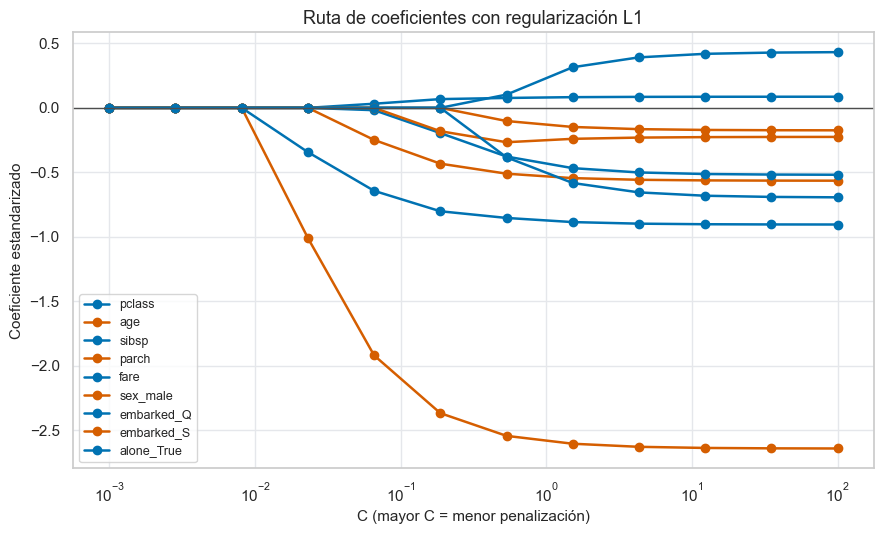

In [3]:
plot_regularization_path(
    C_values,
    coefs,
    feature_names,
    "Ruta de coeficientes con regularización L1",
)
plt.show()


## 3. Tabla de variables sobrevivientes

Aquí "sobrevivientes" significa variables que no fueron llevadas a cero por L1, no pasajeros. Conviene separar este lenguaje de la clase positiva del dataset.


In [4]:
survivors = []
for C, coef in zip(C_values, coefs):
    active = [name for name, value in zip(feature_names, coef) if abs(value) > 1e-6]
    survivors.append({"C": C, "variables_activas": ", ".join(active) if active else "ninguna"})

display(pd.DataFrame(survivors))


,C,variables_activas
0,0.0010,ninguna
1,0.0028,ninguna
2,0.0081,ninguna
3,0.0231,"pclass, sex_male"
4,0.0658,"pclass, age, sibsp, fare, sex_male"
5,0.1874,"pclass, age, sibsp, fare, sex_male, embarked_S"
6,0.5337,"pclass, age, sibsp, parch, fare, sex_male, emb..."
7,1.5199,"pclass, age, sibsp, parch, fare, sex_male, emb..."
8,4.3288,"pclass, age, sibsp, parch, fare, sex_male, emb..."
9,12.3285,"pclass, age, sibsp, parch, fare, sex_male, emb..."


## 4. Coeficientes de un modelo L1 representativo

Elegimos el `C` con mejor AUC de prueba dentro de la ruta. En un flujo real se escogería con validación cruzada; eso se hace en NB07.


C seleccionado para inspección: 0.5337


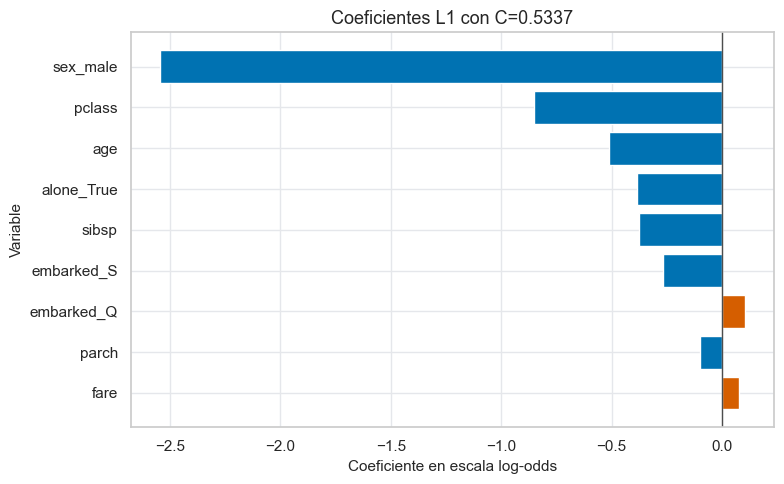

In [5]:
best_C = lasso_results.loc[lasso_results["auc_test"].idxmax(), "C"]
lasso_model = LogisticRegression(
    penalty="l1",
    C=best_C,
    solver="saga",
    max_iter=10000,
    tol=1e-4,
    random_state=RANDOM_STATE,
)
lasso_model.fit(X_train, y_train)

print(f"C seleccionado para inspección: {best_C:.4g}")
plot_coefficients(
    lasso_model.coef_.ravel(),
    feature_names,
    f"Coeficientes L1 con C={best_C:.4g}",
)
plt.show()


## 5. Frontera de decisión L1 en 2D

La frontera 2D usa edad y tarifa. Si L1 pone alguno de esos coeficientes en cero con un `C` fuerte, la frontera se simplifica de forma visible.


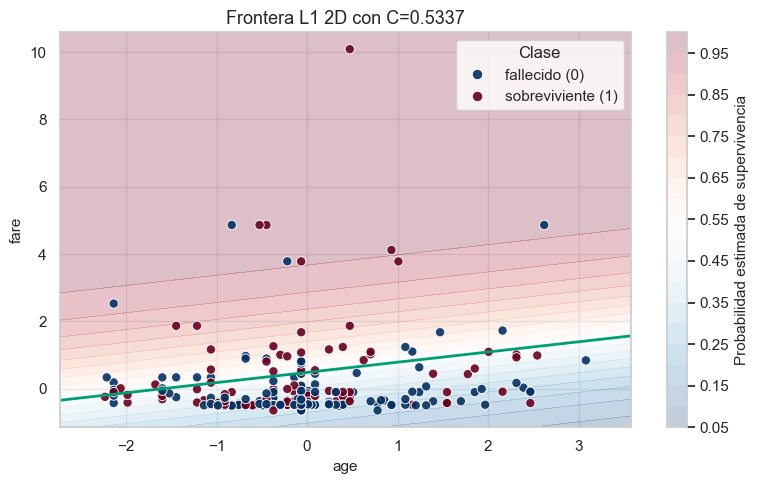

In [6]:
two_features = ["age", "fare"]
model_2d = LogisticRegression(
    penalty="l1",
    C=best_C,
    solver="saga",
    max_iter=10000,
    tol=1e-4,
    random_state=RANDOM_STATE,
)
model_2d.fit(X_train[two_features], y_train)

plot_decision_boundary(
    model_2d,
    X_test[two_features],
    y_test,
    two_features,
    f"Frontera L1 2D con C={best_C:.4g}",
)
plt.show()


## Resumen y conexión con la literatura

Lasso combina encogimiento y selección de variables. A diferencia de L2, su rasgo distintivo es la sparsity. Esta descripción sigue a Tibshirani y a la exposición moderna de Hastie, Tibshirani y Friedman.
